# XGBoost Regressor

## Import Required Libraries

In [1]:
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
import os
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import optuna
import xgboost as xgb
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor

/Users/alanabarrett-frew/Desktop/ML Module/Final Project/ML_Content_Checker/Module-2-Final-Project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Engineered Features

In [2]:
df = pd.read_csv('../feature_engineering.csv')

In [3]:
feature_columns = [
    'word_count', 'average_word_length', 'percent_complex_words', 'percent_difficult_words', 'sentence_count', 'syllables_per_word',
    'polysyllable_count', 'flesch_reading_ease', 'automated_readability_index',
    'dale_chall_readability_score', 'difficult_words', 'linsear_write_formula',
    'spache_readability', 'reading_time'
]

X = df[feature_columns]
y = df['fk_estimated_uk_age_num']

## Model Training and Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=456
)

## Hyperparameter Tuning with GridSearchCV

In [5]:
xgb_model = XGBRegressor(n_estimators=1000, max_depth=7, learning_rate=0.1, subsample=0.7, colsample_bytree=0.8, random_state=456, n_jobs=-1)
xgb_model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=-1, num_parallel_tree=None, ...)

## Save the Trained Model

In [6]:
joblib.dump(xgb_model, '../../models/xgb_model.joblib')

['../../models/xgb_model.joblib']

## Evaluate Results

In [7]:
y_pred = xgb_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
import numpy as np
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print(f"R^2 Score: {r2:.2f}")

y_train_pred = xgb_model.predict(X_train)

mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

print(f"Train MAE: {mae_train:.2f}, Train R^2: {r2_train:.2f}")
print(f"Test MAE: {mae:.2f}, Test R^2: {r2:.2f}")

MAE: 0.29977700114250183
MSE: 0.14720043540000916
RMSE: 0.38366708928445914
R^2 Score: 0.99
Train MAE: 0.00, Train R^2: 1.00
Test MAE: 0.30, Test R^2: 0.99


In [8]:
results = {
    'Model': 'XGBRegressor',
    'MAE': mae,
    'MSE': mse,
    'RMSE': rmse,
    'R2': r2,
    'Params': str(xgb_model.get_params()),
    'Notes': ''
}

In [9]:
results_file = '../all_model_results.csv'

# Turn the results dict into a DataFrame row
df_result = pd.DataFrame([results])

# If file exists, append without headers; else, create with headers
if os.path.isfile(results_file):
    df_result.to_csv(results_file, mode='a', header=False, index=False)
else:
    df_result.to_csv(results_file, index=False)

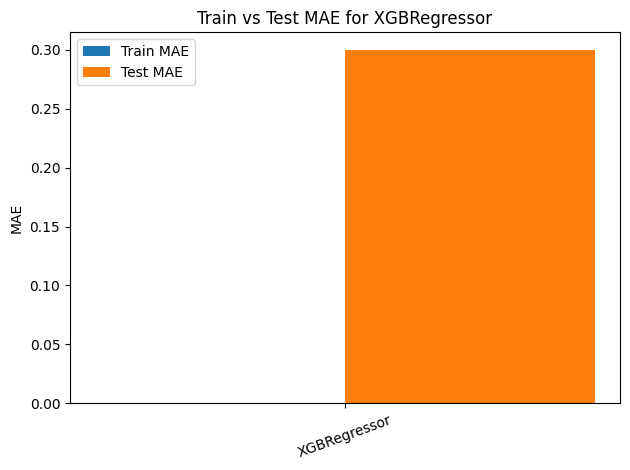

In [10]:
import matplotlib.pyplot as plt

# Visualize train vs test MAE for the XGBRegressor model

models = ['XGBRegressor']
train_mae = [mae_train]
test_mae = [mae]

x = range(len(models))
plt.bar(x, train_mae, width=0.4, label='Train MAE')
plt.bar([i + 0.4 for i in x], test_mae, width=0.4, label='Test MAE')

plt.xticks([i + 0.2 for i in x], models, rotation=20)
plt.ylabel('MAE')
plt.title('Train vs Test MAE for XGBRegressor')
plt.legend()
plt.tight_layout()
plt.show()

## Feature Importance Visualisation

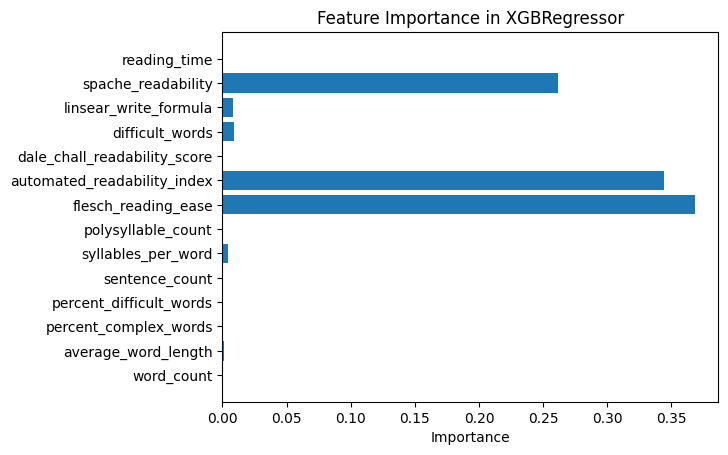

In [11]:
import matplotlib.pyplot as plt

plt.barh(feature_columns, xgb_model.feature_importances_)
plt.xlabel("Importance")
plt.title("Feature Importance in XGBRegressor")
plt.show()

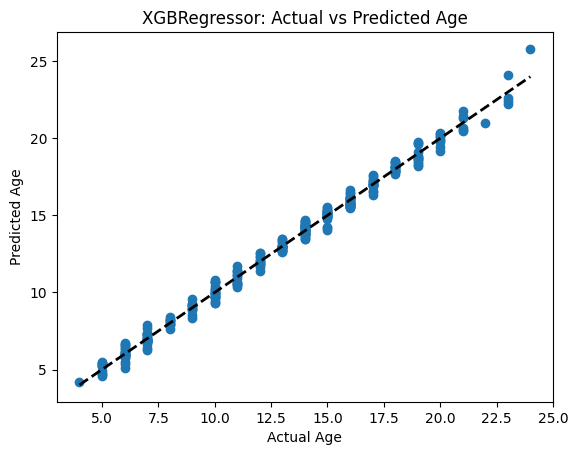

In [12]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("XGBRegressor: Actual vs Predicted Age")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.show()